For this clustering task we will group customers based on behavior such as:

- purchase frequency
- total spending
- average discount received
- profitability
- average delivery time

In [ ]:
import pandas as pd
import numpy as np
from sqlalchemy import create_engine
import matplotlib.pyplot as plt

import os
from dotenv import load_dotenv
from sqlalchemy import create_engine

load_dotenv()

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA



pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")


In [7]:
# Database connection
DB_USER = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD")
DB_HOST = os.getenv("DB_HOST")
DB_NAME = os.getenv("DB_NAME")
PATH_FILE = os.getenv("PATH_FILE")


engine = create_engine(f"mysql+pymysql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}/{DB_NAME}")


In [ ]:
#load data from MySQL database
query = '''
SELECT
    row_id,
    order_id,
    order_date,
    ship_date,
    ship_mode,
    customer_id,
    customer_name,
    segment,
    city,
    state,
    country,
    market,
    region,
    product_id,
    category,
    sub_category,
    product_name,
    sales,
    quantity,
    discount,
    profit,
    shipping_cost,
    order_priority
FROM g_superstore_sorted
'''

df = pd.read_sql(query, engine)

df["order_date"] = pd.to_datetime(df["order_date"])
df["ship_date"] = pd.to_datetime(df["ship_date"])
df["sales"] = pd.to_numeric(df["sales"])
df["quantity"] = pd.to_numeric(df["quantity"])
df["discount"] = pd.to_numeric(df["discount"])
df["profit"] = pd.to_numeric(df["profit"])
df["shipping_cost"] = pd.to_numeric(df["shipping_cost"])

df["delivery_days"] = (df["ship_date"] - df["order_date"]).dt.days
df["profit_margin_pct"] = np.where(df["sales"] != 0, (df["profit"] / df["sales"]) * 100, np.nan)

print(df.shape)
df.head()


(51252, 25)


## Customer-level features

Clustering is  done at the **customer level**, not at the transaction level.

So we aggregate the order data into one row per `customer_id`.


In [ ]:
#Create customer-level table
customer_df = (
    df.groupby(["customer_id", "customer_name", "segment"], as_index=False)
      .agg(
          total_orders=("order_id", "nunique"),
          total_sales=("sales", "sum"),
          total_profit=("profit", "sum"),
          avg_discount=("discount", "mean"),
          avg_delivery_days=("delivery_days", "mean"),
          avg_order_value=("sales", "mean")
      )
)

customer_df["profit_margin_pct"] = np.where(
    customer_df["total_sales"] != 0,
    (customer_df["total_profit"] / customer_df["total_sales"]) * 100,
    np.nan
)

customer_df.head()


In [12]:
# Quick summary
print(customer_df.shape)
customer_df.describe()


(1590, 10)


,total_orders,total_sales,total_profit,avg_discount,avg_delivery_days,avg_order_value,profit_margin_pct
count,"1,590.00","1,590.00","1,590.00","1,590.00","1,590.00","1,590.00","1,590.00"
mean,16.20,"7,943.41",921.19,0.15,3.95,214.86,7.07
std,10.62,"6,925.30","1,324.38",0.11,0.69,104.90,24.18
min,1.00,7.17,"-6,437.34",0.00,0.00,7.17,-217.15
25%,6.00,"1,674.81",94.81,0.09,3.62,134.58,4.72
50%,14.00,"6,248.13",591.36,0.14,4.00,214.51,12.57
75%,26.00,"13,125.62","1,613.99",0.19,4.33,276.78,18.98
max,41.00,"35,668.14","8,787.48",0.70,7.00,902.75,45.11



These are the behavior variables used to define customer groups.


In [13]:
# Feature selection
feature_cols = [
    "total_orders",
    "total_sales",
    "total_profit",
    "avg_discount",
    "profit_margin_pct",
    "avg_delivery_days",
    "avg_order_value"
]

X = customer_df[feature_cols].copy()
X = X.replace([np.inf, -np.inf], np.nan).dropna()

# Keep customer table aligned with the cleaned feature matrix
customer_model_df = customer_df.loc[X.index].copy()

print(X.shape)
X.head()


(1590, 7)


,total_orders,total_sales,total_profit,avg_discount,profit_margin_pct,avg_delivery_days,avg_order_value
0,19,"13,747.42",447.71,0.10,3.26,3.79,327.32
1,23,"5,884.19",677.48,0.17,11.51,3.50,140.10
2,19,"17,563.45","1,504.63",0.08,8.57,4.32,474.69
3,36,"15,343.90","3,051.43",0.13,19.89,3.62,210.19
4,7,"2,243.25",535.56,0.22,23.87,5.25,280.41


Clustering is distance-based, so scaling is important.  
Without scaling, variables like `total_sales` would dominate smaller-scale variables like `avg_discount`.


In [14]:
# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled[:5]


array([[ 0.26418372,  0.8383526 , -0.35762188, -0.46518817, -0.15787166,
        -0.24601439,  1.07232184],
       [ 0.64099657, -0.29744056, -0.18407483,  0.11084873,  0.18372066,
        -0.66227654, -0.71291795],
       [ 0.26418372,  1.38955366,  0.44067791, -0.67495843,  0.0618122 ,
         0.53869601,  2.47755693],
       [ 1.86563833,  1.0689539 ,  1.60898783, -0.26092361,  0.53013188,
        -0.49263546, -0.04456641],
       [-0.86625482, -0.823351  , -0.2912681 ,  0.64341114,  0.69509162,
         1.88732912,  0.62497888]])

#### Using the elbow method for KMeans

This helps us choose a reasonable number of clusters.


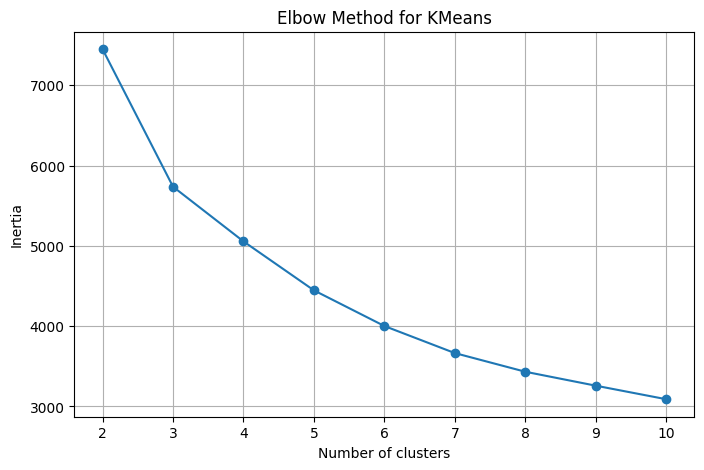

In [15]:
# Elbow method
inertia = []
cluster_range = range(2, 11)

for k in cluster_range:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)
    inertia.append(model.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(list(cluster_range), inertia, marker="o")
plt.title("Elbow Method for KMeans")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()


In [26]:
print("The elbow plot suggests that 4 clusters (customer segments) is a good choice based on bending of the curve at k= 4")

The elbow plot suggests that 4 clusters (customer segments) is a good choice based on bending of the curve at k= 4


## Fit KMeans

We start with KMeans because it is the easiest clustering model to interpret in a business project.

Based on the elbow chart, we will use `n_clusters`=4


In [29]:
# KMeans clustering
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
customer_model_df["kmeans_cluster"] = kmeans.fit_predict(X_scaled)

sil_score = silhouette_score(X_scaled, customer_model_df["kmeans_cluster"])
print(f"Silhouette Score (KMeans): {sil_score:.4f}")

customer_model_df.head()


Silhouette Score (KMeans): 0.2551


,customer_id,customer_name,segment,total_orders,total_sales,total_profit,avg_discount,avg_delivery_days,avg_order_value,profit_margin_pct,kmeans_cluster,agg_cluster,dbscan_cluster
0,AA-10315,Alex Avila,Consumer,19,"13,747.42",447.71,0.10,3.79,327.32,3.26,2,1,0
1,AA-10375,Allen Armold,Consumer,23,"5,884.19",677.48,0.17,3.50,140.10,11.51,2,1,0
2,AA-10480,Andrew Allen,Consumer,19,"17,563.45","1,504.63",0.08,4.32,474.69,8.57,1,1,0
3,AA-10645,Anna Andreadi,Consumer,36,"15,343.90","3,051.43",0.13,3.62,210.19,19.89,1,1,0
4,AA-315,Alex Avila,Consumer,7,"2,243.25",535.56,0.22,5.25,280.41,23.87,0,0,0


In [ ]:
print("Based on the Silhouette score, we can say that customer behavior shows moderate natural segmentation, not random, but not perfectly separated either.")


Based on the Silhouette score, we can say that customer behavior shows moderate natural segmentation, not random, but not perfectly separated either.


## Profile the KMeans clusters

We summarize each cluster to understand what kind of customers it contains.


In [17]:
# KMeans cluster profile
kmeans_profile = (
    customer_model_df.groupby("kmeans_cluster", as_index=False)[feature_cols]
    .mean()
    .sort_values("total_sales", ascending=False)
)

kmeans_profile


,kmeans_cluster,total_orders,total_sales,total_profit,avg_discount,profit_margin_pct,avg_delivery_days,avg_order_value
1,1,27.58,"18,319.39","3,048.14",0.12,17.37,3.97,332.44
2,2,24.90,"11,699.60","1,049.82",0.14,9.59,3.98,246.14
0,0,6.72,"2,179.43",363.07,0.11,16.27,3.98,168.72
3,3,6.09,"1,561.87",-509.68,0.37,-41.56,3.80,115.31


In [3]:
print("\n Cluster Profiles (Customer Segments behavioral characteristics)")
print("-----------------")
print("cluster0: low orders, low sales, low profit, good profit margin")
print("These are low engangement customers (potentially at risk) \n")
print("cluster1: high orders, high sales, high profit, good margin")
print("These are high value loyal customers \n")
print("cluster2: high orders, high sales, moderate profit, low_profit margin")
print("These areActive but price-sensitive customers \n")
print("cluster3: low orders, low sales, loss, very poor profit margin (-tive)")
print("These are loss-making customers (Not-risky to lose) \n")


 Cluster Profiles (Customer Segments behavioral characteristics)
-----------------
cluster0: low orders, low sales, low profit, good profit margin
These are low engangement customers (potentially at risk) 

cluster1: high orders, high sales, high profit, good margin
These are high value loyal customers 

cluster2: high orders, high sales, moderate profit, low_profit margin
These areActive but price-sensitive customers 

cluster3: low orders, low sales, loss, very poor profit margin (-tive)
These are loss-making customers (Not-risky to lose) 



In [33]:
cluster_sizes = (
    customer_model_df["kmeans_cluster"]
    .value_counts()
    .sort_index()
    .rename_axis("kmeans_cluster")
    .reset_index(name="customers")
)

cluster_sizes


,kmeans_cluster,customers
0,0,597
1,1,255
2,2,543
3,3,195


## Visualize the customer clusters

PCA is used only for 2D visualization.  
The actual clustering still uses the full feature set.


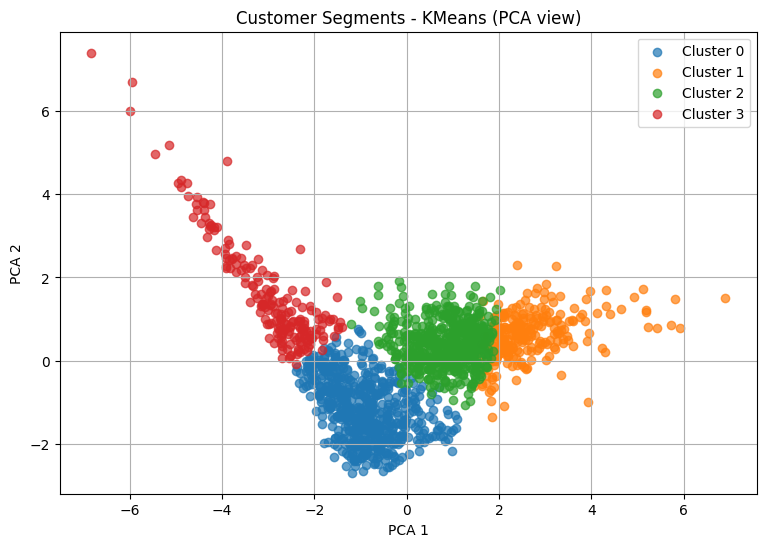

In [19]:
#  PCA visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plot_df = customer_model_df.copy()
plot_df["pca_1"] = X_pca[:, 0]
plot_df["pca_2"] = X_pca[:, 1]

plt.figure(figsize=(9, 6))
for cluster in sorted(plot_df["kmeans_cluster"].unique()):
    subset = plot_df[plot_df["kmeans_cluster"] == cluster]
    plt.scatter(subset["pca_1"], subset["pca_2"], label=f"Cluster {cluster}", alpha=0.7)

plt.title("Customer Segments - KMeans (PCA view)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend()
plt.grid(True)
plt.show()


## Exploring: Agglomerative Clustering

This gives a second segmentation approach to compare with KMeans.


In [20]:
# ---------- Agglomerative clustering   ------------
agg_model = AgglomerativeClustering(n_clusters=4)
customer_model_df["agg_cluster"] = agg_model.fit_predict(X_scaled)

agg_sil_score = silhouette_score(X_scaled, customer_model_df["agg_cluster"])
print(f"Silhouette Score (Agglomerative): {agg_sil_score:.4f}")


Silhouette Score (Agglomerative): 0.2726


In [21]:
agg_profile = (
    customer_model_df.groupby("agg_cluster", as_index=False)[feature_cols]
    .mean()
    .sort_values("total_sales", ascending=False)
)

agg_profile


,agg_cluster,total_orders,total_sales,total_profit,avg_discount,profit_margin_pct,avg_delivery_days,avg_order_value
3,3,28.73,"21,211.91","4,105.26",0.12,19.44,3.98,361.61
1,1,25.87,"12,890.88","1,344.74",0.14,10.64,3.98,252.50
0,0,6.59,"2,343.50",344.76,0.13,13.82,3.98,178.73
2,2,5.89,"1,314.00",-602.26,0.39,-54.38,3.68,99.27


## Try DBSCAN

DBSCAN is useful when one wants to detect dense groups and possible outliers.

It may label some customers as `-1`, which means noise / outliers.


In [22]:
# ---------- DBSCAN clustering -------
dbscan = DBSCAN(eps=1.2, min_samples=10)
customer_model_df["dbscan_cluster"] = dbscan.fit_predict(X_scaled)

customer_model_df["dbscan_cluster"].value_counts().sort_index()


dbscan_cluster
-1     112
 0    1478
Name: count, dtype: int64

In [34]:
print("About 112 customers behave very differently from the majority and may represent unusual purchasing behavior.")

About 112 customers behave very differently from the majority and may represent unusual purchasing behavior.


In [23]:
dbscan_valid = customer_model_df["dbscan_cluster"] != -1

if dbscan_valid.sum() > 1 and customer_model_df.loc[dbscan_valid, "dbscan_cluster"].nunique() > 1:
    dbscan_score = silhouette_score(X_scaled[dbscan_valid], customer_model_df.loc[dbscan_valid, "dbscan_cluster"])
    print(f"Silhouette Score (DBSCAN, excluding noise): {dbscan_score:.4f}")
else:
    print("DBSCAN did not produce enough non-noise clusters for silhouette scoring.")


DBSCAN did not produce enough non-noise clusters for silhouette scoring.


Customer behavior does not form multiple dense natural clusters under DBSCAN assumptions. KMeans works better in such cases as it forces segmentation.

In [24]:
dbscan_profile = (
    customer_model_df.groupby("dbscan_cluster", as_index=False)[feature_cols]
    .mean()
    .sort_values("total_sales", ascending=False)
)

dbscan_profile


,dbscan_cluster,total_orders,total_sales,total_profit,avg_discount,profit_margin_pct,avg_delivery_days,avg_order_value
1,0,16.69,"8,001.89",949.03,0.15,9.77,3.97,209.56
0,-1,9.65,"7,171.66",553.80,0.27,-28.50,3.69,284.88


## Label the KMeans segments with business-friendly names

This step is manual and should be based on the cluster profile table.

The mapping below is only a starting example.  
After you inspect the profile, update the names to match the actual behavior.


In [ ]:
# =========================
# 13. Create segment names
# =========================
segment_map = {
    0: "Segment A",
    1: "Segment B",
    2: "Segment C",
    3: "Segment D"
}

customer_model_df["customer_segment"] = customer_model_df["kmeans_cluster"].map(segment_map)

customer_model_df[[
    "customer_id",
    "customer_name",
    "segment",
    "total_orders",
    "total_sales",
    "total_profit",
    "avg_discount",
    "profit_margin_pct",
    "customer_segment"
]].head(10)


## Save the final customer segmentation table

This final table can be exported to CSV or pushed back into MySQL for dashboards and reporting.


In [ ]:
# =========================
# 14. Save outputs
# =========================
final_customer_segments = customer_model_df[[
    "customer_id",
    "customer_name",
    "segment",
    "total_orders",
    "total_sales",
    "total_profit",
    "avg_discount",
    "avg_delivery_days",
    "avg_order_value",
    "profit_margin_pct",
    "kmeans_cluster",
    "agg_cluster",
    "dbscan_cluster",
    "customer_segment"
]].copy()

final_customer_segments.to_csv("customer_segmentation_results.csv", index=False)

final_customer_segments.head()


In [ ]:
# Optional: save back to MySQL
# final_customer_segments.to_sql(
#     name="customer_segmentation_results",
#     con=engine,
#     if_exists="replace",
#     index=False
# )


## Final notes

For a portfolio project, KMeans is usually the best model to present because:

- it is easy to explain
- the segments are easy to summarize
- the business story is clearer

Suggested final interpretation style:

- high-value loyal customers
- discount-sensitive customers
- low-frequency low-value customers
- high-profit niche customers

Once you inspect the cluster profiles, you can rename the segments accordingly in the report.
